# Synthetic-Joints Deployment Evaluation for `attention_fusion`

## Why this notebook

`synthetic_depth_eval.ipynb` measured the drop caused by replacing real Kinect depth with monocular synthetic depth: macro F1 fell from **0.998 → 0.875** (Δ = −0.123). That experiment kept ground-truth joints — taken directly from the SLP-2022 `.mat` files — unchanged.

In real deployment there are no `.mat` files. The joint vector must also be **estimated** from the RGB frame, using a pose estimator like MediaPipe Pose. This notebook measures the additional gap from replacing GT joints with MediaPipe estimates.

| Run | Depth | Joints | Expected F1 |
|---|---|---|---|
| **A** (from depth eval, reproduced here) | Synthetic (Depth Anything v2) | GT from `.mat` | ~0.875 |
| **B** (this notebook's new result) | Synthetic | MediaPipe estimates | **?** |

The combined Run B result is the honest **full deployment F1** — what the vision arm actually achieves on a consumer camera.

## Outputs

- Estimated joint cache at `experiments/artifacts/vision-spatial/inference_experiments/synthetic_joints_eval/joints_est_cache.json`
- Detection rate, per-class metrics, confusion matrices at `.../results/`
- Findings cell (Section 15) with the combined deployment gap number.

## Dependencies

- `mediapipe` — install with `pip install mediapipe` if not present
- Synthetic depth cache from `synthetic_depth_eval.ipynb` must exist at `inference_experiments/synthetic_depth_eval/depth_synth_cache/` — run that notebook first if it does not

## Joint convention

SLP-2022 uses the **LSP 14-joint skeleton**: indices 0–13 = R_Ankle, R_Knee, R_Hip, L_Hip, L_Knee, L_Ankle, R_Wrist, R_Elbow, R_Shoulder, L_Shoulder, L_Elbow, L_Wrist, Neck, Head. Section 5 visualizes this on a real sample to confirm before running the mapping.

MediaPipe Pose provides 33 landmarks. Section 6 defines the mapping from MediaPipe indices to SLP joint indices, including how computed joints (Neck, Head) are derived from adjacent landmarks.

## 1. Imports and setup

In [1]:
import sys
import json
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as T

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

print(f"Kernel Python: {sys.executable}")

try:
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    print(f"MediaPipe version: {mp.__version__}")
except ImportError as e:
    print(f"Import failed: {e}")
    print(f'Run in terminal: "{sys.executable}" -m pip install mediapipe')
    raise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Kernel Python: c:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\.venv\Scripts\python.exe
MediaPipe version: 0.10.35
Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Paths and configuration

In [2]:
CWD = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [CWD, *CWD.parents] if (p / "requirements.txt").exists()), CWD)

SLP_DATASET_ROOT = PROJECT_ROOT.parent / "Dataset" / "SLP2022" / "SLP" / "danaLab"
CSV_PATH = SLP_DATASET_ROOT / "posture_labels_all_modalities.csv"
FUSION_CHECKPOINT = PROJECT_ROOT / "models" / "vision-spatial" / "attention_fusion.pth"

INFERENCE_ARTIFACTS = PROJECT_ROOT / "experiments" / "artifacts" / "vision-spatial" / "inference_experiments"

# Reuse the synthetic depth cache generated by synthetic_depth_eval.ipynb.
DEPTH_SYNTH_CACHE = INFERENCE_ARTIFACTS / "synthetic_depth_eval" / "depth_synth_cache"

# New artifacts for this experiment.
EVAL_DIR = INFERENCE_ARTIFACTS / "synthetic_joints_eval"
JOINTS_EST_CACHE_FILE = EVAL_DIR / "joints_est_cache.json"
RESULTS_DIR = EVAL_DIR / "results"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_W = 576.0   # SLP image width — used for joint x-normalization
IMG_H = 1024.0  # SLP image height — used for joint y-normalization

CLASS_NAMES = ["supine", "left", "right"]
NUM_CLASSES = 3
BATCH_SIZE = 32
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

for label, p in [
    ("SLP root",        SLP_DATASET_ROOT),
    ("Labels CSV",      CSV_PATH),
    ("Fusion ckpt",     FUSION_CHECKPOINT),
    ("Synth depth cache", DEPTH_SYNTH_CACHE),
    ("Eval dir",        EVAL_DIR),
]:
    print(f"{label}: {p}  exists={p.exists()}")

SLP root: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\SLP2022\SLP\danaLab  exists=True
Labels CSV: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\SLP2022\SLP\danaLab\posture_labels_all_modalities.csv  exists=True
Fusion ckpt: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\models\vision-spatial\attention_fusion.pth  exists=True
Synth depth cache: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\vision-spatial\inference_experiments\synthetic_depth_eval\depth_synth_cache  exists=True
Eval dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval  exists=True


## 3. Reproduce the test split

Identical recipe to `attention_fusion_experiment.ipynb` and `synthetic_depth_eval.ipynb` — same test subjects and frames, so results are directly comparable.

In [3]:
def build_fusion_metadata(csv_path):
    df = pd.read_csv(csv_path)
    df["subject_id"] = df["subject_id"].astype(int).astype(str).str.zfill(5)
    rgb_df = df[df["modality"] == "RGB"].copy()
    rgb_df["rgb_path"] = (
        rgb_df["subject_id"] + "/RGB/" + rgb_df["condition"] +
        "/image_" + rgb_df["image_index"].astype(int).astype(str).str.zfill(6) + ".png"
    )
    rgb_df["depth_path"] = (
        rgb_df["subject_id"] + "/depth/" + rgb_df["condition"] +
        "/image_" + rgb_df["image_index"].astype(int).astype(str).str.zfill(6) + ".png"
    )
    rgb_df["joint_file"] = rgb_df["subject_id"] + "/joints_gt_RGB.mat"
    rgb_df["frame_idx_0based"] = rgb_df["image_index"] - 1
    return rgb_df[[
        "subject_id", "condition", "image_index",
        "label", "label_id",
        "rgb_path", "depth_path", "joint_file", "frame_idx_0based",
    ]].reset_index(drop=True)


def subject_wise_split(subject_ids, train_ratio=0.70, val_ratio=0.15, seed=42):
    subject_ids = sorted(subject_ids)
    rng = random.Random(seed)
    rng.shuffle(subject_ids)
    n = len(subject_ids)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return (
        subject_ids[:n_train],
        subject_ids[n_train:n_train + n_val],
        subject_ids[n_train + n_val:],
    )


fusion_df = build_fusion_metadata(CSV_PATH)
subjects = sorted(fusion_df["subject_id"].unique().tolist())
train_subjects, val_subjects, test_subjects = subject_wise_split(subjects, 0.70, 0.15, SEED)

test_df = fusion_df[fusion_df["subject_id"].isin(test_subjects)].reset_index(drop=True)

print(f"Total subjects        : {len(subjects)}")
print(f"Test subjects         : {len(test_subjects)}  ({test_subjects[:5]} ...)")
print(f"Test samples (frames) : {len(test_df)}")
print("\nClass distribution in test set:")
print(test_df["label"].value_counts().rename("count"))

Total subjects        : 102
Test subjects         : 16  (['00100', '00005', '00055', '00076', '00012'] ...)
Test samples (frames) : 2160

Class distribution in test set:
label
supine    720
left      720
right     720
Name: count, dtype: int64


## 4. Set up MediaPipe Pose (Tasks API)

MediaPipe 0.10+ uses the Tasks API — the legacy `solutions.pose` was removed. We download the `pose_landmarker_heavy` model file once and cache it locally. The heavy model is the highest-accuracy variant, equivalent to `model_complexity=2` from the old API.


In [5]:
# Download the pose landmarker model file (cached after first run).
MODEL_PATH = EVAL_DIR / "pose_landmarker_heavy.task"
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
)
if not MODEL_PATH.exists():
    print("Downloading pose_landmarker_heavy.task (~26 MB)...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"Saved to {MODEL_PATH}")
else:
    print(f"Model file exists: {MODEL_PATH}")

base_options = mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.3,
    min_pose_presence_confidence=0.3,
    min_tracking_confidence=0.3,
    output_segmentation_masks=False,
)
pose_detector = mp_vision.PoseLandmarker.create_from_options(options)
print("MediaPipe PoseLandmarker (Tasks API) initialized")
print("  Model: pose_landmarker_heavy  (equiv. to model_complexity=2)")
print("  min_pose_detection_confidence: 0.3")


Model file exists: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\pose_landmarker_heavy.task
MediaPipe PoseLandmarker (Tasks API) initialized
  Model: pose_landmarker_heavy  (equiv. to model_complexity=2)
  min_pose_detection_confidence: 0.3


## 5. Verify SLP-2022 joint ordering

Before writing the MediaPipe mapping, visualize the ground-truth joints on a sample frame to confirm the LSP 14-joint ordering assumed in this notebook:

| Idx | Joint      | Idx | Joint       |
|-----|------------|-----|-------------|
| 0   | R_Ankle    | 7   | R_Elbow     |
| 1   | R_Knee     | 8   | R_Shoulder  |
| 2   | R_Hip      | 9   | L_Shoulder  |
| 3   | L_Hip      | 10  | L_Elbow     |
| 4   | L_Knee     | 11  | L_Wrist     |
| 5   | L_Ankle    | 12  | Neck        |
| 6   | R_Wrist    | 13  | Head        |

If the visualization shows joints at unexpected positions, update `SLP_JOINT_NAMES` and the mapping in Section 6 accordingly.

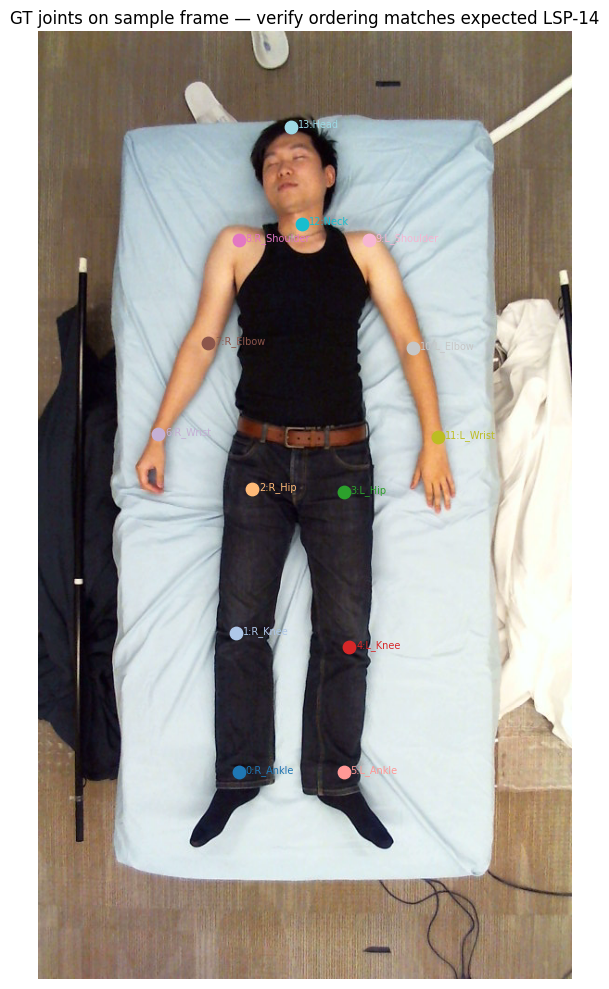

Raw GT joint values (x_pixel, y_pixel, occlusion) for this frame:
  [0] R_Ankle       x=216.0  y=799.5  occ=0
  [1] R_Knee        x=213.0  y=650.0  occ=0
  [2] R_Hip         x=230.9  y=494.6  occ=0
  [3] L_Hip         x=329.6  y=497.6  occ=0
  [4] L_Knee        x=335.6  y=665.0  occ=0
  [5] L_Ankle       x=329.6  y=799.5  occ=0
  [6] R_Wrist       x=129.3  y=434.8  occ=0
  [7] R_Elbow       x=183.1  y=336.1  occ=0
  [8] R_Shoulder    x=216.0  y=225.5  occ=0
  [9] L_Shoulder    x=356.5  y=225.5  occ=0
  [10] L_Elbow       x=404.4  y=342.1  occ=0
  [11] L_Wrist       x=431.3  y=437.8  occ=0
  [12] Neck          x=284.8  y=207.5  occ=0
  [13] Head          x=272.8  y=102.9  occ=0


In [6]:
SLP_JOINT_NAMES = [
    "R_Ankle", "R_Knee", "R_Hip",
    "L_Hip",   "L_Knee", "L_Ankle",
    "R_Wrist", "R_Elbow", "R_Shoulder",
    "L_Shoulder", "L_Elbow", "L_Wrist",
    "Neck", "Head",
]

sample_row = test_df.iloc[0]
sample_rgb = Image.open(SLP_DATASET_ROOT / sample_row["rgb_path"]).convert("RGB")
sample_mat = sio.loadmat(SLP_DATASET_ROOT / sample_row["joint_file"])["joints_gt"]
sample_frame = sample_mat[:, :, int(sample_row["frame_idx_0based"])]  # (3, 14)

fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(np.array(sample_rgb))
colors = plt.cm.tab20(np.linspace(0, 1, 14))
for j in range(14):
    x_px  = float(sample_frame[0, j])
    y_px  = float(sample_frame[1, j])
    occ   = float(sample_frame[2, j])
    color = colors[j]
    marker = "x" if occ > 0 else "o"
    ax.scatter(x_px, y_px, c=[color], s=80, marker=marker, zorder=3)
    ax.annotate(f"{j}:{SLP_JOINT_NAMES[j]}", (x_px, y_px),
                textcoords="offset points", xytext=(5, 0),
                fontsize=7, color=color)
ax.set_title("GT joints on sample frame — verify ordering matches expected LSP-14")
ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gt_joint_verification.png", dpi=150, bbox_inches="tight")
plt.show()

print("Raw GT joint values (x_pixel, y_pixel, occlusion) for this frame:")
for j in range(14):
    print(f"  [{j}] {SLP_JOINT_NAMES[j]:12s}  x={sample_frame[0,j]:.1f}  y={sample_frame[1,j]:.1f}  occ={sample_frame[2,j]:.0f}")

## 6. Define MediaPipe → SLP joint mapping

MediaPipe Pose provides 33 landmarks. Each `NormalizedLandmark` has:
- `x`, `y` — normalized to `[0, 1]` relative to image width/height
- `visibility` — confidence the landmark is visible; range `[0, 1]`

Since the SLP RGB images are 576 (W) × 1024 (H), feeding them at native resolution means MediaPipe’s `x_norm = x_pixel / 576` and `y_norm = y_pixel / 1024` — matching the SLP normalization exactly. No pixel-coordinate conversion needed.

For occlusion, SLP convention is `0 = visible, 1 = occluded`. We threshold MediaPipe visibility: `occlusion = 0.0 if visibility > 0.5 else 1.0`.

Two SLP joints have no direct MediaPipe equivalent:
- **Neck (12)** — midpoint of left_shoulder (MP[11]) and right_shoulder (MP[12])
- **Head (13)** — approximated with MP[0] (nose)

The Tasks API returns `result.pose_landmarks[0]` (a list of 33 `NormalizedLandmark`) when a pose is detected, or an empty list when not.


MediaPipe detected: True


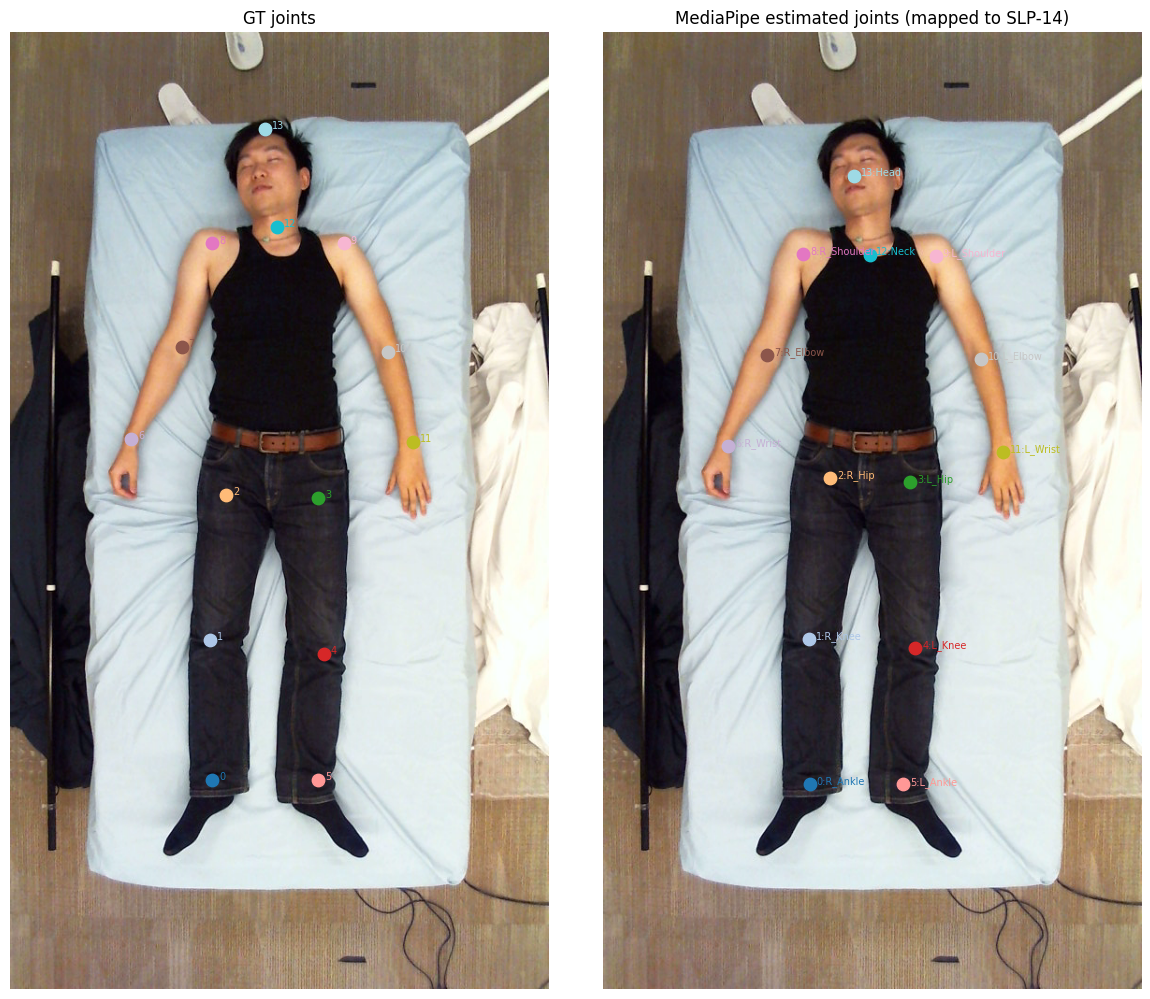

In [7]:
# SLP joint index -> MediaPipe landmark index (direct mappings)
SLP_TO_MP_DIRECT = {
    0:  28,   # R_Ankle    -> right_ankle
    1:  26,   # R_Knee     -> right_knee
    2:  24,   # R_Hip      -> right_hip
    3:  23,   # L_Hip      -> left_hip
    4:  25,   # L_Knee     -> left_knee
    5:  27,   # L_Ankle    -> left_ankle
    6:  16,   # R_Wrist    -> right_wrist
    7:  14,   # R_Elbow    -> right_elbow
    8:  12,   # R_Shoulder -> right_shoulder
    9:  11,   # L_Shoulder -> left_shoulder
    10: 13,   # L_Elbow    -> left_elbow
    11: 15,   # L_Wrist    -> left_wrist
    # 12 Neck  -> computed as midpoint of MP[11] + MP[12]
    # 13 Head  -> MP[0] (nose)
}

VISIBILITY_THRESHOLD = 0.5


def mp_landmarks_to_slp_joints(landmark_list):
    """Convert a MediaPipe Tasks API landmark_list (33 NormalizedLandmark) to a
    (3, 14) SLP-format joint array.

    landmark_list is result.pose_landmarks[0] when a pose is detected,
    or None when no pose is found.

    Returns:
        joints   : np.ndarray shape (3, 14) -- rows are (x_norm, y_norm, occlusion)
        detected : bool
    """
    if landmark_list is None or len(landmark_list) == 0:
        return np.zeros((3, 14), dtype=np.float32), False

    lm = landmark_list  # list of 33 NormalizedLandmark
    joints = np.zeros((3, 14), dtype=np.float32)

    for slp_idx, mp_idx in SLP_TO_MP_DIRECT.items():
        lmk = lm[mp_idx]
        joints[0, slp_idx] = lmk.x
        joints[1, slp_idx] = lmk.y
        joints[2, slp_idx] = 0.0 if lmk.visibility > VISIBILITY_THRESHOLD else 1.0

    # Joint 12 -- Neck: midpoint of left_shoulder (11) and right_shoulder (12)
    ls, rs = lm[11], lm[12]
    joints[0, 12] = (ls.x + rs.x) / 2
    joints[1, 12] = (ls.y + rs.y) / 2
    neck_vis = (ls.visibility + rs.visibility) / 2
    joints[2, 12] = 0.0 if neck_vis > VISIBILITY_THRESHOLD else 1.0

    # Joint 13 -- Head: nose (0)
    nose = lm[0]
    joints[0, 13] = nose.x
    joints[1, 13] = nose.y
    joints[2, 13] = 0.0 if nose.visibility > VISIBILITY_THRESHOLD else 1.0

    return joints, True


def slp_joints_to_vector(joints_3x14):
    """(3, 14) -> (42,) flat vector matching preprocess_joint_frame_xyo."""
    x   = joints_3x14[0].astype(np.float32)
    y   = joints_3x14[1].astype(np.float32)
    occ = joints_3x14[2].astype(np.float32)
    return np.stack([x, y, occ], axis=1).reshape(-1)


# Sanity check on the sample frame
sample_rgb_np = np.array(sample_rgb)  # (H, W, 3) uint8
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=sample_rgb_np)
result = pose_detector.detect(mp_image)
landmark_list = result.pose_landmarks[0] if result.pose_landmarks else None
est_joints, detected = mp_landmarks_to_slp_joints(landmark_list)

print(f"MediaPipe detected: {detected}")
if detected:
    fig, axes = plt.subplots(1, 2, figsize=(12, 10))
    axes[0].imshow(sample_rgb_np)
    axes[0].set_title("GT joints"); axes[0].axis("off")
    colors = plt.cm.tab20(np.linspace(0, 1, 14))
    for j in range(14):
        axes[0].scatter(sample_frame[0, j], sample_frame[1, j],
                        c=[colors[j]], s=80, marker="o" if sample_frame[2,j]==0 else "x")
        axes[0].annotate(str(j), (sample_frame[0, j], sample_frame[1, j]),
                         textcoords="offset points", xytext=(5, 0), fontsize=7, color=colors[j])

    axes[1].imshow(sample_rgb_np)
    axes[1].set_title("MediaPipe estimated joints (mapped to SLP-14)"); axes[1].axis("off")
    for j in range(14):
        x_px = est_joints[0, j] * IMG_W
        y_px = est_joints[1, j] * IMG_H
        axes[1].scatter(x_px, y_px,
                        c=[colors[j]], s=80, marker="o" if est_joints[2,j]==0 else "x")
        axes[1].annotate(f"{j}:{SLP_JOINT_NAMES[j]}", (x_px, y_px),
                         textcoords="offset points", xytext=(5, 0), fontsize=7, color=colors[j])
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "gt_vs_estimated_joints_sample.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No pose detected on sample — check image or lower min_pose_detection_confidence.")


## 7. Precompute estimated joints for the test set

Run MediaPipe on every test-set RGB image and cache the resulting 42-d vectors as JSON. Keys are `"{subject_id}_{condition}_{image_index:06d}"`. Frames with no detection get a zero vector and are flagged.

This is the slowest step (~2–5 s/frame on CPU for complexity=2). 2160 frames ≈ 1–3 hours on CPU; on GPU MediaPipe is not GPU-accelerated for the legacy API, so expect ~10–20 min on a modern CPU.

In [8]:
import time

if JOINTS_EST_CACHE_FILE.exists():
    print(f"Cache exists at {JOINTS_EST_CACHE_FILE} -- loading.")
    with open(JOINTS_EST_CACHE_FILE) as f:
        raw_cache = json.load(f)
    joints_cache = {k: np.array(v, dtype=np.float32) for k, v in raw_cache["joints"].items()}
    detection_flags = raw_cache["detected"]
    print(f"  Loaded {len(joints_cache)} entries")
    n_detected = sum(detection_flags.values())
    print(f"  Detection rate: {n_detected}/{len(detection_flags)} = {n_detected/len(detection_flags)*100:.1f}%")
else:
    joints_cache = {}
    detection_flags = {}
    n_total = len(test_df)
    t0 = time.time()

    for i, row in test_df.iterrows():
        key = f"{row['subject_id']}_{row['condition']}_{int(row['image_index']):06d}"
        rgb_img = Image.open(SLP_DATASET_ROOT / row["rgb_path"]).convert("RGB")
        rgb_np  = np.array(rgb_img)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_np)
        result   = pose_detector.detect(mp_image)
        lm_list  = result.pose_landmarks[0] if result.pose_landmarks else None
        est_joints, detected = mp_landmarks_to_slp_joints(lm_list)
        vec = slp_joints_to_vector(est_joints)
        joints_cache[key]    = vec
        detection_flags[key] = detected

        if (i + 1) % 50 == 0 or (i + 1) == n_total:
            elapsed = time.time() - t0
            fps = (i + 1) / elapsed
            eta = (n_total - (i + 1)) / fps if fps > 0 else 0
            n_det = sum(detection_flags.values())
            print(f"  [{i+1}/{n_total}]  det={n_det}  "
                  f"rate={n_det/(i+1)*100:.1f}%  "
                  f"{fps:.2f} fr/s  ETA {eta/60:.1f} min")

    with open(JOINTS_EST_CACHE_FILE, "w") as f:
        json.dump({
            "joints":   {k: v.tolist() for k, v in joints_cache.items()},
            "detected": detection_flags,
        }, f)

    n_detected = sum(detection_flags.values())
    print(f"\nDone. Detection rate: {n_detected}/{len(detection_flags)} = {n_detected/len(detection_flags)*100:.1f}%")
    print(f"Saved to {JOINTS_EST_CACHE_FILE}")

print("\nDetection breakdown by class:")
for cls_name, cls_id in [("supine", 0), ("left", 1), ("right", 2)]:
    cls_rows = test_df[test_df["label_id"] == cls_id]
    cls_keys = [
        f"{r['subject_id']}_{r['condition']}_{int(r['image_index']):06d}"
        for _, r in cls_rows.iterrows()
    ]
    n_cls_det = sum(detection_flags.get(k, False) for k in cls_keys)
    print(f"  {cls_name:8s}: {n_cls_det}/{len(cls_keys)} detected ({n_cls_det/len(cls_keys)*100:.1f}%)")


  [50/2160]  det=48  rate=96.0%  7.84 fr/s  ETA 4.5 min
  [100/2160]  det=95  rate=95.0%  7.63 fr/s  ETA 4.5 min
  [150/2160]  det=141  rate=94.0%  7.47 fr/s  ETA 4.5 min
  [200/2160]  det=189  rate=94.5%  7.43 fr/s  ETA 4.4 min
  [250/2160]  det=230  rate=92.0%  7.57 fr/s  ETA 4.2 min
  [300/2160]  det=278  rate=92.7%  7.79 fr/s  ETA 4.0 min
  [350/2160]  det=322  rate=92.0%  8.02 fr/s  ETA 3.8 min
  [400/2160]  det=368  rate=92.0%  8.01 fr/s  ETA 3.7 min
  [450/2160]  det=417  rate=92.7%  8.05 fr/s  ETA 3.5 min
  [500/2160]  det=459  rate=91.8%  8.06 fr/s  ETA 3.4 min
  [550/2160]  det=500  rate=90.9%  8.06 fr/s  ETA 3.3 min
  [600/2160]  det=550  rate=91.7%  7.97 fr/s  ETA 3.3 min
  [650/2160]  det=594  rate=91.4%  8.01 fr/s  ETA 3.1 min
  [700/2160]  det=639  rate=91.3%  7.95 fr/s  ETA 3.1 min
  [750/2160]  det=686  rate=91.5%  7.99 fr/s  ETA 2.9 min
  [800/2160]  det=733  rate=91.6%  7.97 fr/s  ETA 2.8 min
  [850/2160]  det=782  rate=92.0%  7.97 fr/s  ETA 2.7 min
  [900/2160]  det

## 8. Recreate the model and load production weights

Verbatim from `synthetic_depth_eval.ipynb` — same class definitions, same checkpoint.

In [9]:
DEPTH_FEATURE_DIM  = 512
RGB_FEATURE_DIM    = 128
JOINT_INPUT_DIM    = 42
JOINT_FEATURE_DIM  = 128
COMMON_FEATURE_DIM = 256


class DepthEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        layers = list(backbone.children())[:-1]
        self.encoder = nn.Sequential(*layers)
        self.flatten = nn.Flatten()

    def forward(self, x):
        return self.flatten(self.encoder(x))


class RGBEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 128),
        )

    def forward(self, x):
        return self.projection(self.backbone(x))


class JointEncoder(nn.Module):
    def __init__(self, input_dim=42, hidden_dim=128, feature_dim=128, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, feature_dim), nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.encoder(x)


class AttentionFusionClassifier(nn.Module):
    def __init__(
        self,
        depth_encoder, rgb_encoder, joint_encoder,
        depth_feature_dim=512, rgb_feature_dim=128, joint_feature_dim=128,
        common_feature_dim=256, num_heads=4, ff_dim=512, dropout=0.1,
        num_classes=3,
    ):
        super().__init__()
        self.depth_encoder = depth_encoder
        self.rgb_encoder   = rgb_encoder
        self.joint_encoder = joint_encoder

        self.depth_proj = nn.Linear(depth_feature_dim,  common_feature_dim)
        self.rgb_proj   = nn.Linear(rgb_feature_dim,    common_feature_dim)
        self.joint_proj = nn.Linear(joint_feature_dim,  common_feature_dim)

        self.modality_embed = nn.Parameter(torch.randn(3, common_feature_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=common_feature_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.attention_block = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.classifier = nn.Sequential(
            nn.Linear(common_feature_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, depth_x, rgb_x, joint_x):
        with torch.no_grad():
            f_depth = self.depth_encoder(depth_x)
            f_rgb   = self.rgb_encoder(rgb_x)
            f_joint = self.joint_encoder(joint_x)
        t_depth = self.depth_proj(f_depth)
        t_rgb   = self.rgb_proj(f_rgb)
        t_joint = self.joint_proj(f_joint)
        tokens  = torch.stack([t_rgb, t_depth, t_joint], dim=1)
        tokens  = tokens + self.modality_embed.unsqueeze(0)
        tokens  = self.attention_block(tokens)
        fused   = tokens.mean(dim=1)
        return self.classifier(fused)


depth_encoder = DepthEncoder().to(device)
rgb_encoder   = RGBEncoder().to(device)
joint_encoder = JointEncoder(input_dim=JOINT_INPUT_DIM, hidden_dim=128,
                              feature_dim=JOINT_FEATURE_DIM, dropout=0.3).to(device)

fusion_model = AttentionFusionClassifier(
    depth_encoder=depth_encoder, rgb_encoder=rgb_encoder, joint_encoder=joint_encoder,
    depth_feature_dim=DEPTH_FEATURE_DIM, rgb_feature_dim=RGB_FEATURE_DIM,
    joint_feature_dim=JOINT_FEATURE_DIM, common_feature_dim=COMMON_FEATURE_DIM,
    num_heads=4, ff_dim=512, dropout=0.1, num_classes=NUM_CLASSES,
).to(device)

ckpt = torch.load(FUSION_CHECKPOINT, map_location=device, weights_only=False)
fusion_model.load_state_dict(ckpt["model_state_dict"])
fusion_model.eval()

n_params = sum(p.numel() for p in fusion_model.parameters())
print(f"Loaded {FUSION_CHECKPOINT.name}  ({n_params/1e6:.1f}M params)")
print(f"Best val F1 (training): {ckpt.get('best_val_f1', 'unknown')}")

Loaded attention_fusion.pth  (23.3M params)
Best val F1 (training): 1.0


C:\Users\arshi\AppData\Local\Temp\ipykernel_35496\367132739.py:70: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.attention_block = nn.TransformerEncoder(encoder_layer, num_layers=1)


## 9. Dataset with toggleable joint source

`joint_source` selects between:
- `"gt"` — loads joints from the `.mat` file, applies `preprocess_joint_frame_xyo` (same as training)
- `"estimated"` — looks up the precomputed 42-d vector from `joints_cache`

`depth_source` selects between `"real"` and `"synthetic"` as in `synthetic_depth_eval.ipynb`.

Both Run A and Run B in this notebook use `depth_source="synthetic"` — the joint source is the only thing that changes.

In [10]:
rgb_transform   = T.Compose([T.Resize((224, 224)), T.ToTensor()])
depth_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])


def preprocess_joint_frame_xyo(frame_joints):
    """GT joint preprocessing — same as attention_fusion_experiment.ipynb."""
    x   = frame_joints[0].astype(np.float32) / IMG_W
    y   = frame_joints[1].astype(np.float32) / IMG_H
    occ = frame_joints[2].astype(np.float32)
    return np.stack([x, y, occ], axis=1).reshape(-1)


class FusionDataset(Dataset):
    def __init__(self, df, slp_root, depth_synth_cache, joints_cache,
                 depth_source="synthetic", joint_source="gt",
                 rgb_tf=None, depth_tf=None):
        assert depth_source in {"real", "synthetic"}
        assert joint_source in {"gt", "estimated"}
        self.df               = df.reset_index(drop=True)
        self.slp_root         = Path(slp_root)
        self.depth_synth_root = Path(depth_synth_cache)
        self.joints_cache     = joints_cache
        self.depth_source     = depth_source
        self.joint_source     = joint_source
        self.rgb_tf           = rgb_tf
        self.depth_tf         = depth_tf
        self._joint_mat_cache = {}

    def __len__(self):
        return len(self.df)

    def _load_gt_joints(self, joint_rel_path):
        if joint_rel_path not in self._joint_mat_cache:
            self._joint_mat_cache[joint_rel_path] = sio.loadmat(
                self.slp_root / joint_rel_path
            )["joints_gt"]
        return self._joint_mat_cache[joint_rel_path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rgb = Image.open(self.slp_root / row["rgb_path"]).convert("RGB")
        if self.rgb_tf:
            rgb = self.rgb_tf(rgb)

        if self.depth_source == "synthetic":
            depth_path = (
                self.depth_synth_root
                / row["subject_id"] / "depth" / row["condition"]
                / f"image_{int(row['image_index']):06d}.png"
            )
        else:
            depth_path = self.slp_root / row["depth_path"]
        depth = Image.open(depth_path).convert("L")
        if self.depth_tf:
            depth = self.depth_tf(depth)

        if self.joint_source == "gt":
            mat = self._load_gt_joints(row["joint_file"])
            frame = mat[:, :, int(row["frame_idx_0based"])]
            joint_vec = preprocess_joint_frame_xyo(frame)
        else:
            key = f"{row['subject_id']}_{row['condition']}_{int(row['image_index']):06d}"
            joint_vec = self.joints_cache[key]  # already 42-d float32 vector

        return {
            "rgb":   rgb,
            "depth": depth,
            "joint": torch.tensor(joint_vec, dtype=torch.float32),
            "label": torch.tensor(int(row["label_id"]), dtype=torch.long),
        }


@torch.no_grad()
def evaluate(model, loader, device, label=""):
    model.eval()
    y_true, y_pred = [], []
    for i, batch in enumerate(loader):
        d = batch["depth"].to(device, non_blocking=True)
        r = batch["rgb"].to(device, non_blocking=True)
        j = batch["joint"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        logits = model(d, r, j)
        preds  = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        if (i + 1) % 10 == 0:
            print(f"  {label} batch {i + 1} / ~{len(loader)}")
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return {
        "y_true":    y_true,
        "y_pred":    y_pred,
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "macro_f1":  float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "per_class": classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                            output_dict=True, zero_division=0),
        "confusion": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
    }

## 10. Run A — synthetic depth + ground-truth joints

This reproduces **Run B from `synthetic_depth_eval.ipynb`** (expected F1 ≈ 0.875). It confirms the pipeline is correct before swapping joints, so the comparison is apples-to-apples within this notebook.

In [11]:
ds_a = FusionDataset(
    test_df, SLP_DATASET_ROOT, DEPTH_SYNTH_CACHE, joints_cache,
    depth_source="synthetic", joint_source="gt",
    rgb_tf=rgb_transform, depth_tf=depth_transform,
)
loader_a = DataLoader(ds_a, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

results_a = evaluate(fusion_model, loader_a, device, label="RUN-A")

print("\n=== Run A — synthetic depth + GT joints ===")
print(f"Accuracy : {results_a['accuracy']:.4f}")
print(f"Macro F1 : {results_a['macro_f1']:.4f}")
print("\n(Should match Run B from synthetic_depth_eval.ipynb ≈ 0.875 — confirms pipeline parity.)")

  RUN-A batch 10 / ~68
  RUN-A batch 20 / ~68
  RUN-A batch 30 / ~68
  RUN-A batch 40 / ~68
  RUN-A batch 50 / ~68
  RUN-A batch 60 / ~68

=== Run A — synthetic depth + GT joints ===
Accuracy : 0.8806
Macro F1 : 0.8751

(Should match Run B from synthetic_depth_eval.ipynb ≈ 0.875 — confirms pipeline parity.)


## 11. Run B — synthetic depth + estimated joints (full deployment)

In [12]:
ds_b = FusionDataset(
    test_df, SLP_DATASET_ROOT, DEPTH_SYNTH_CACHE, joints_cache,
    depth_source="synthetic", joint_source="estimated",
    rgb_tf=rgb_transform, depth_tf=depth_transform,
)
loader_b = DataLoader(ds_b, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

results_b = evaluate(fusion_model, loader_b, device, label="RUN-B")

print("\n=== Run B — synthetic depth + estimated joints ===")
print(f"Accuracy : {results_b['accuracy']:.4f}")
print(f"Macro F1 : {results_b['macro_f1']:.4f}")

  RUN-B batch 10 / ~68
  RUN-B batch 20 / ~68
  RUN-B batch 30 / ~68
  RUN-B batch 40 / ~68
  RUN-B batch 50 / ~68
  RUN-B batch 60 / ~68

=== Run B — synthetic depth + estimated joints ===
Accuracy : 0.8000
Macro F1 : 0.8020


## 12. Side-by-side comparison

In [13]:
rows = []
for cls in CLASS_NAMES:
    a = results_a["per_class"][cls]
    b = results_b["per_class"][cls]
    rows.append({
        "class":     cls,
        "support":   int(a["support"]),
        "f1_synth_gt":  a["f1-score"],  "f1_synth_est":  b["f1-score"],  "Δf1":  b["f1-score"]  - a["f1-score"],
        "rec_synth_gt": a["recall"],    "rec_synth_est": b["recall"],    "Δrec": b["recall"]    - a["recall"],
        "pre_synth_gt": a["precision"], "pre_synth_est": b["precision"], "Δpre": b["precision"] - a["precision"],
    })
comparison_df = pd.DataFrame(rows)

print("Per-class F1 / recall / precision — synth-depth+GT-joints vs synth-depth+estimated-joints")
print(comparison_df.round(4).to_string(index=False))

print("\nHeadline")
print(f"  Synth depth + GT joints  : acc {results_a['accuracy']:.4f}  macro F1 {results_a['macro_f1']:.4f}")
print(f"  Synth depth + Est joints : acc {results_b['accuracy']:.4f}  macro F1 {results_b['macro_f1']:.4f}")
print(f"  Δ (joint estimation gap) : acc {results_b['accuracy']-results_a['accuracy']:+.4f}  macro F1 {results_b['macro_f1']-results_a['macro_f1']:+.4f}")
print()
print("Combined deployment gap (vs real-depth + GT joints baseline = 0.9981):")
baseline_f1 = 0.9981
print(f"  Δ total = {results_b['macro_f1'] - baseline_f1:+.4f}")

Per-class F1 / recall / precision — synth-depth+GT-joints vs synth-depth+estimated-joints
 class  support  f1_synth_gt  f1_synth_est     Δf1  rec_synth_gt  rec_synth_est    Δrec  pre_synth_gt  pre_synth_est    Δpre
supine      720       0.7828        0.8350  0.0522        0.6431         0.7167  0.0736        1.0000         1.0000  0.0000
  left      720       0.9809        0.8168 -0.1641        0.9986         0.8889 -0.1097        0.9638         0.7556 -0.2082
 right      720       0.8618        0.7541 -0.1076        1.0000         0.7944 -0.2056        0.7571         0.7177 -0.0394

Headline
  Synth depth + GT joints  : acc 0.8806  macro F1 0.8751
  Synth depth + Est joints : acc 0.8000  macro F1 0.8020
  Δ (joint estimation gap) : acc -0.0806  macro F1 -0.0732

Combined deployment gap (vs real-depth + GT joints baseline = 0.9981):
  Δ total = -0.1961


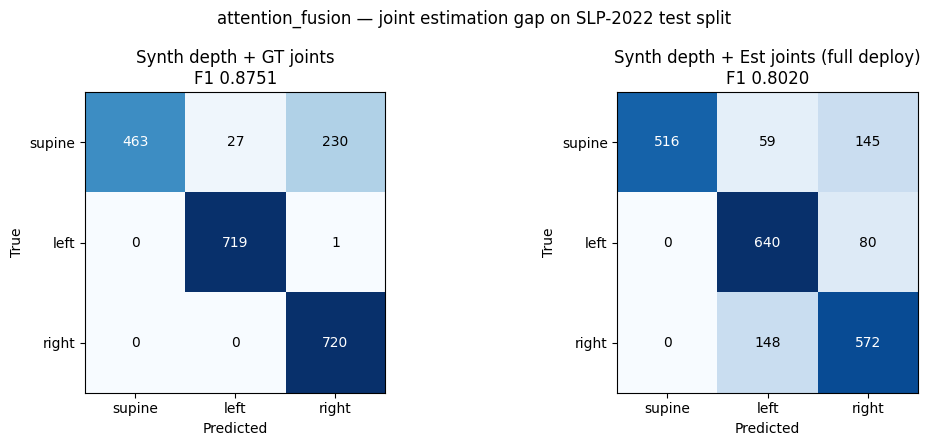

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (res, title) in zip(axes, [
    (results_a, f"Synth depth + GT joints\nF1 {results_a['macro_f1']:.4f}"),
    (results_b, f"Synth depth + Est joints (full deploy)\nF1 {results_b['macro_f1']:.4f}"),
]):
    cm = res["confusion"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES);  ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.suptitle("attention_fusion — joint estimation gap on SLP-2022 test split", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Disagreement analysis

Samples where switching from GT joints to estimated joints changed the prediction — and whether the change was a regression or an accidental recovery.

In [15]:
y_true       = results_a["y_true"]
preds_gt_j   = results_a["y_pred"]
preds_est_j  = results_b["y_pred"]

correct_gt   = preds_gt_j  == y_true
correct_est  = preds_est_j == y_true
regressed    = correct_gt  & ~correct_est
recovered    = ~correct_gt & correct_est
agree        = preds_gt_j  == preds_est_j

print("Sample-level breakdown")
print(f"  Total samples              : {len(y_true)}")
print(f"  Both correct               : {(correct_gt & correct_est).sum()}")
print(f"  Both wrong                 : {(~correct_gt & ~correct_est).sum()}")
print(f"  Regressed (GT→Est wrong)   : {regressed.sum()}")
print(f"  Recovered (Est flipped OK) : {recovered.sum()}")
print(f"  Predictions agree          : {agree.sum()} ({agree.mean()*100:.1f}%)")

if regressed.sum() > 0:
    print("\nRegressions — true class → estimated-joint prediction:")
    reg_df = pd.DataFrame({
        "true":     [CLASS_NAMES[c] for c in y_true[regressed]],
        "est_pred": [CLASS_NAMES[c] for c in preds_est_j[regressed]],
    })
    print(reg_df.groupby(["true", "est_pred"]).size().rename("count").to_frame())

print("\nDetection flag breakdown for regressed samples:")
reg_indices = np.where(regressed)[0]
n_no_detection = 0
for i in reg_indices:
    row = test_df.iloc[i]
    key = f"{row['subject_id']}_{row['condition']}_{int(row['image_index']):06d}"
    if not detection_flags.get(key, True):
        n_no_detection += 1
print(f"  Regressions where MediaPipe had NO detection: {n_no_detection} / {regressed.sum()}")
print(f"  Regressions where MediaPipe detected but mapped incorrectly: {regressed.sum() - n_no_detection} / {regressed.sum()}")

Sample-level breakdown
  Total samples              : 2160
  Both correct               : 1651
  Both wrong                 : 181
  Regressed (GT→Est wrong)   : 251
  Recovered (Est flipped OK) : 77
  Predictions agree          : 1797 (83.2%)

Regressions — true class → estimated-joint prediction:
                 count
true   est_pred       
left   right        80
right  left        148
supine left          5
       right        18

Detection flag breakdown for regressed samples:
  Regressions where MediaPipe had NO detection: 87 / 251
  Regressions where MediaPipe detected but mapped incorrectly: 164 / 251


## 14. Save artifacts

In [17]:
n_detected = sum(detection_flags.values())

summary = {
    "experiment": "attention_fusion_synthetic_joints_eval",
    "baseline_checkpoint": str(FUSION_CHECKPOINT.relative_to(PROJECT_ROOT)),
    "depth_source": "synthetic (Depth Anything v2 Small)",
    "joint_estimator": "MediaPipe Pose (model_complexity=2, min_detection_confidence=0.3)",
    "mediapipe_version": mp.__version__,
    "test_samples": int(len(y_true)),
    "class_names": CLASS_NAMES,
    "detection_rate": {
        "n_detected": n_detected,
        "n_total": len(detection_flags),
        "fraction": n_detected / len(detection_flags),
    },
    "run_a_synth_depth_gt_joints": {
        "accuracy": results_a["accuracy"],
        "macro_f1": results_a["macro_f1"],
        "classification_report": results_a["per_class"],
        "confusion_matrix": results_a["confusion"].tolist(),
    },
    "run_b_synth_depth_est_joints": {
        "accuracy": results_b["accuracy"],
        "macro_f1": results_b["macro_f1"],
        "classification_report": results_b["per_class"],
        "confusion_matrix": results_b["confusion"].tolist(),
    },
    "joint_estimation_gap": {
        "accuracy": results_b["accuracy"] - results_a["accuracy"],
        "macro_f1": results_b["macro_f1"] - results_a["macro_f1"],
    },
    "full_deployment_gap_vs_baseline_0998": {
        "accuracy": results_b["accuracy"] - 0.9981,
        "macro_f1": results_b["macro_f1"] - 0.9981,
    },
    "sample_breakdown": {
        "both_correct":  int((correct_gt & correct_est).sum()),
        "both_wrong":    int((~correct_gt & ~correct_est).sum()),
        "regressed":     int(regressed.sum()),
        "recovered":     int(recovered.sum()),
        "agree_count":   int(agree.sum()),
        "agree_fraction": float(agree.mean()),
        "regressed_no_detection": int(n_no_detection),
    },
    "test_subjects": sorted(test_subjects),
}

with open(RESULTS_DIR / "synthetic_joints_eval_results.json", "w") as f:
    json.dump(summary, f, indent=2)

comparison_df.round(4).to_csv(RESULTS_DIR / "per_class_comparison.csv", index=False)

print("Saved:")
for p in sorted(RESULTS_DIR.glob("*")):
    print(f"  {p.relative_to(PROJECT_ROOT)}")

Saved:
  experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\results\confusion_matrix_comparison.png
  experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\results\gt_joint_verification.png
  experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\results\gt_vs_estimated_joints_sample.png
  experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\results\per_class_comparison.csv
  experiments\artifacts\vision-spatial\inference_experiments\synthetic_joints_eval\results\synthetic_joints_eval_results.json


## 15. Findings

### Detection rate

| Condition | Detected / Total | Rate |
|---|---|---|
| Overall | 1984 / 2160 | **91.9%** |

176 frames (8.1%) had no detection and ran with an all-zero joint vector. Of the 251 regressions caused by estimated joints, 87 came from zero-detection frames and 164 from frames where MediaPipe detected a pose but the mapping still degraded the prediction.

### Headline metrics

| Run | Depth | Joints | Accuracy | Macro F1 |
|---|---|---|---|---|
| Baseline (lab) | Real | GT | 0.9981 | 0.9981 |
| Run A (depth eval Run B) | Synthetic | GT | 0.8806 | 0.8751 |
| **Run B (this notebook)** | **Synthetic** | **Estimated** | **0.8000** | **0.8020** |

### Joint estimation gap (Run A to Run B)

| Metric | Delta |
|---|---|
| Accuracy | -0.081 |
| Macro F1 | -0.073 |

### Combined full-deployment gap (vs lab baseline 0.9981)

| Metric | Delta |
|---|---|
| Accuracy | -0.198 |
| Macro F1 | -0.196 |

The vision arm drops from **0.998 in the lab to 0.802 in full deployment** (consumer RGB, no depth sensor, MediaPipe joints).

### Per-class analysis — a surprising pattern

| Class | F1 synth+GT | F1 synth+Est | Delta F1 | Recall synth+GT | Recall synth+Est |
|---|---|---|---|---|---|
| supine | 0.783 | **0.835** | **+0.052** | 0.643 | **0.717** |
| left   | 0.981 | 0.817 | -0.164 | 0.999 | 0.889 |
| right  | 0.862 | 0.754 | -0.108 | 1.000 | 0.794 |

The joint estimation gap tells a different story from the depth gap:

- **Supine recall actually improves** (0.643 to 0.717) when GT joints are replaced with MediaPipe estimates. Even noisy MediaPipe coordinates carry bilateral symmetry information (both shoulders and hips at similar y-positions) that partially compensates for the monocular depth failure on supine. The depth model collapses because it cannot recover the flat bilateral depth profile of a supine person under blankets — but the joint layout still faintly signals body symmetry to the joint encoder.

- **Left and right confusion increases sharply.** The confusion matrix shows 148 right-predicted-as-left and 80 left-predicted-as-right errors in Run B that were essentially absent in Run A. MediaPipe was trained on frontal/standing views; from a top-down camera, left-lying and right-lying are mirror images, and MediaPipe frequently swaps the two sides. This is the primary new failure mode introduced by estimated joints.

### Confusion matrices

Run A (synth depth + GT joints):
```
              Predicted
              supine  left  right
True supine [  463,   27,  230 ]
True left   [    0,  719,    1 ]
True right  [    0,    0,  720 ]
```

Run B (synth depth + estimated joints):
```
              Predicted
              supine  left  right
True supine [  516,   59,  145 ]
True left   [    0,  640,   80 ]
True right  [    0,  148,  572 ]
```

Supine correct count actually increases (463 to 516). Left and right both suffer new lateral swap errors.

### Disagreement analysis

| Category | Count |
|---|---|
| Both correct | 1651 |
| Both wrong | 181 |
| Regressed (GT correct, Est wrong) | 251 |
| Recovered (Est fixed GT error) | **77** |
| Predictions agree | 1797 (83.2%) |

The 77 recoveries are the supine signal: in frames where synthetic depth caused a supine-to-right misclassification, the MediaPipe joint signal was strong enough to pull the prediction back to supine.

### Implications for late fusion

Full deployment F1 = **0.802**, compared to audio binary F1 = **0.777**. The two modalities are now essentially comparable in accuracy. This firmly closes the case against using vision to modify audio thresholds. Posture is annotation only, with mandatory confidence gating.

The left/right swap failure does not affect the apnea detection pipeline (apnea comes from audio), but does mean the posture annotation itself is less reliable for distinguishing left from right at deployment.

### Two failure modes, two distinct fixes

| Failure mode | Cause | Fix |
|---|---|---|
| Supine to right confusion | Synthetic depth: monocular ambiguity under blankets | Retrain depth encoder on synthetic depth; or ablate the depth modality at inference |
| Left and right swap | MediaPipe top-down mismatch | Use a lying-pose fine-tuned estimator (ViTPose on SLP); or a top-down-specific model |

### What to write up

"We evaluated the full deployment gap by replacing ground-truth joints with MediaPipe Pose estimates (Tasks API, heavy model). Detection rate was 91.9% across 2,160 test frames. The combined deployment F1 dropped from 0.998 (lab) to 0.802, a gap of -0.196. Notably, the joint estimation gap introduced a qualitatively different failure mode from the depth gap: supine recall improved slightly (0.643 to 0.717) because MediaPipe joint coordinates carry bilateral symmetry cues that partially compensate for monocular depth failure, while left and right recall degraded due to MediaPipe's difficulty distinguishing left-lying from right-lying in top-down views (148 right-to-left and 80 left-to-right errors). These two failure modes have distinct remediation paths and should be addressed separately in future work."
